# SQ26 — ISIC Rev.5 Classification Report

This notebook produces every table and figure required for the SQ26 submission report:
- Section histogram per repository (primary classification)
- Top-20 class table with comments per repository
- Top-15 division bar chart per repository (secondary classification)
- Cross-repository summary tables
- Confidence distribution
- Classifier comparison
- File-level classification results

In [101]:
import os
import sqlite3
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.patches import Patch
from IPython.display import display

# Vector graphics — all figures render as SVG so they can be zoomed in without pixelation
%config InlineBackend.figure_format = 'svg'

DB = "23692652-sq26-classification.db"
conn = sqlite3.connect(DB)

REPO_NAMES = {1: "Zenodo", 10: "Harvard Dataverse", }

ISIC_SECTIONS = {
    "A": "Agriculture, forestry and fishing",
    "B": "Mining and quarrying",
    "C": "Manufacturing",
    "D": "Electricity, gas, steam and air conditioning supply",
    "E": "Water supply; sewerage, waste management and remediation activities",
    "F": "Construction",
    "G": "Wholesale and retail trade; repair of motor vehicles and motorcycles",
    "H": "Transportation and storage",
    "I": "Accommodation and food service activities",
    "J": "Publishing, broadcasting, and content production",
    "K": "Telecommunications, computer programming, consulting and infrastructure",
    "L": "Financial and insurance activities",
    "M": "Real estate activities",
    "N": "Professional, scientific and technical activities",
    "O": "Administrative and support service activities",
    "P": "Public administration and defence; compulsory social security",
    "Q": "Education",
    "R": "Human health and social work activities",
    "S": "Arts, sports and recreation",
    "T": "Other service activities",
    "U": "Activities of households as employers; undifferentiated goods- and services-producing activities of households for own use",
    "V": "Activities of extraterritorial organizations and bodies",
}

SEC_COLORS = {
    "A": "#2E7D32", "B": "#4E342E", "C": "#E65100", "D": "#F9A825",
    "E": "#00838F", "F": "#546E7A", "G": "#AD1457", "H": "#6A1B9A",
    "I": "#880E4F", "J": "#1565C0", "K": "#0277BD", "L": "#00695C",
    "M": "#558B2F", "N": "#1565C0", "O": "#4527A0", "P": "#283593",
    "Q": "#01579B", "R": "#BF360C", "S": "#827717", "T": "#37474F",
    "U": "#795548", "V": "#616161",
}

BLUE_DARK  = "#1F4E79"
BLUE_LIGHT = "#90CAF9"
GRID_COLOR = "#E0E0E0"
img_dir = "report_images"
# Confidence: sequential blue ramp (dark → light = very_high → low)
CONF_COLORS = {
    "very_high": "#1F4E79",
    "high":      "#2E75B6",
    "medium":    "#6DA7EC",
    "low":       "#BDD7EE",
}
CONF_ORDER  = ["very_high", "high", "medium", "low"]
CONF_LABELS = {"very_high": "Very High", "high": "High", "medium": "Medium", "low": "Low"}


plt.rcParams.update({"font.size": 10})
print("Setup complete — SVG vector output enabled.")

Setup complete — SVG vector output enabled.


---
## Part 1 — Overview Tables
### Table 1 — Repository Summary

In [102]:
df_repos = pd.read_sql("""
    SELECT p.repository_id,
           COUNT(*) as total_projects,
           SUM(CASE WHEN p.type='QD_PROJECT'  THEN 1 ELSE 0 END) as QD_PROJECT,
           SUM(CASE WHEN p.type='QDA_PROJECT' THEN 1 ELSE 0 END) as QDA_PROJECT,
           SUM(CASE WHEN p.type='OTHER_PROJECT' THEN 1 ELSE 0 END) as OTHER_PROJECT,
           SUM(CASE WHEN p.type='NOT_A_PROJECT' THEN 1 ELSE 0 END) as NOT_A_PROJECT,
           COUNT(cv.id) as classified
    FROM projects p
    LEFT JOIN classifications_vote cv ON cv.project_id = p.id
    GROUP BY p.repository_id ORDER BY p.repository_id
""", conn)

df_repos["Repository"] = df_repos["repository_id"].map(REPO_NAMES)
df_repos = df_repos[["Repository","total_projects","QD_PROJECT","QDA_PROJECT","OTHER_PROJECT","NOT_A_PROJECT","classified"]]
df_repos.columns = ["Repository","Total","QD_PROJECT","QDA_PROJECT","OTHER_PROJECT","NOT_A_PROJECT","Classified"]

totals = df_repos.select_dtypes(include="number").sum()
totals_row = pd.DataFrame([["TOTAL"] + totals.tolist()], columns=df_repos.columns)
df_repos_display = pd.concat([df_repos, totals_row], ignore_index=True)

display(df_repos_display.style
    .format({c: "{:,.0f}" for c in df_repos_display.columns if c != "Repository"})
    .set_properties(**{"text-align": "right"})
    .set_properties(subset=["Repository"], **{"text-align": "left"})
    .apply(lambda x: ["font-weight:bold; background-color:#1F4E79; color:white"]*len(x)
           if x["Repository"]=="TOTAL" else [""]*len(x), axis=1)
    .set_caption("Table 1 — Project counts per repository and type")
)

,Repository,Total,QD_PROJECT,QDA_PROJECT,OTHER_PROJECT,NOT_A_PROJECT,Classified
0,Zenodo,"39,393","27,655",42,"10,180","1,516","39,393"
1,Harvard Dataverse,"12,400","7,022",22,"5,115",241,"12,400"
2,nan,25,0,0,0,25,25
3,TOTAL,"51,818","34,677",64,"15,295","1,782","51,818"


### Table 2 — Confidence Distribution (Ensemble Vote)

In [103]:
df_conf = pd.read_sql("""
    SELECT p.repository_id, cv.confidence, COUNT(*) as count
    FROM classifications_vote cv
    JOIN projects p ON p.id = cv.project_id
    GROUP BY p.repository_id, cv.confidence
""", conn)

df_conf["repository"] = df_conf["repository_id"].map(REPO_NAMES)
pivot = df_conf.pivot_table(index="repository", columns="confidence", values="count", fill_value=0)
order = [c for c in ["very_high","high","medium","low"] if c in pivot.columns]
pivot = pivot[order]
pivot["Total"] = pivot.sum(axis=1)
pivot["%high+very_high"] = ((pivot.get("very_high",0) + pivot.get("high",0)) / pivot["Total"] * 100).round(1)

display(pivot.style
    .format({c: "{:,.0f}" for c in order + ["Total"]})
    .format({"%high+very_high": "{:.1f}%"})
    .bar(subset=["%high+very_high"], color="#9DC3E6")
    .set_caption("Table 2 — Confidence distribution of ensemble vote per repository")
)

confidence,very_high,high,medium,low,Total,%high+very_high
repository,,,,,,
Harvard Dataverse,5285.000000,4566.000000,2317.000000,232.000000,12400.000000,79.4%
Zenodo,17254.000000,14217.000000,7373.000000,549.000000,39393.000000,79.9%


### Table 3 — Classifier Agreement Comparison

In [104]:
data = [
    {"Classifier": "LLM ensemble (Qwen/Mistral/Claude)", "Table": "classifications_combined",
     "Agreement vs Qwen": "reference", "Agreement vs Claude": "reference",
     "Division Coverage": "38%", "Priority": 1},
    {"Classifier": "bert-base-uncased (fine-tuned)", "Table": "classifications_bert_base",
     "Agreement vs Qwen": "74.0%", "Agreement vs Claude": "77.6%",
     "Division Coverage": "0%", "Priority": 2},
    {"Classifier": "DistilBERT + ISIC PDF anchors", "Table": "classifications_bert_division",
     "Agreement vs Qwen": "75.1%", "Agreement vs Claude": "40.9%",
     "Division Coverage": "100%", "Priority": 3},
    {"Classifier": "TF-IDF + Logistic Regression", "Table": "classifications_tfidf",
     "Agreement vs Qwen": "70.1%", "Agreement vs Claude": "69.6%",
     "Division Coverage": "0%", "Priority": 4},
]
df_clf = pd.DataFrame(data)
display(df_clf.style
    .set_properties(**{"text-align": "left"})
    .hide(axis="index")
    .set_caption("Table 3 — Section agreement and division coverage per classifier")
)

Classifier,Table,Agreement vs Qwen,Agreement vs Claude,Division Coverage,Priority
LLM ensemble (Qwen/Mistral/Claude),classifications_combined,reference,reference,38%,1
bert-base-uncased (fine-tuned),classifications_bert_base,74.0%,77.6%,0%,2
DistilBERT + ISIC PDF anchors,classifications_bert_division,75.1%,40.9%,100%,3
TF-IDF + Logistic Regression,classifications_tfidf,70.1%,69.6%,0%,4



---
## Part 2 — Per-Repository Figures
### Figure 1a — ISIC Section Histogram · Zenodo (Repo 1)

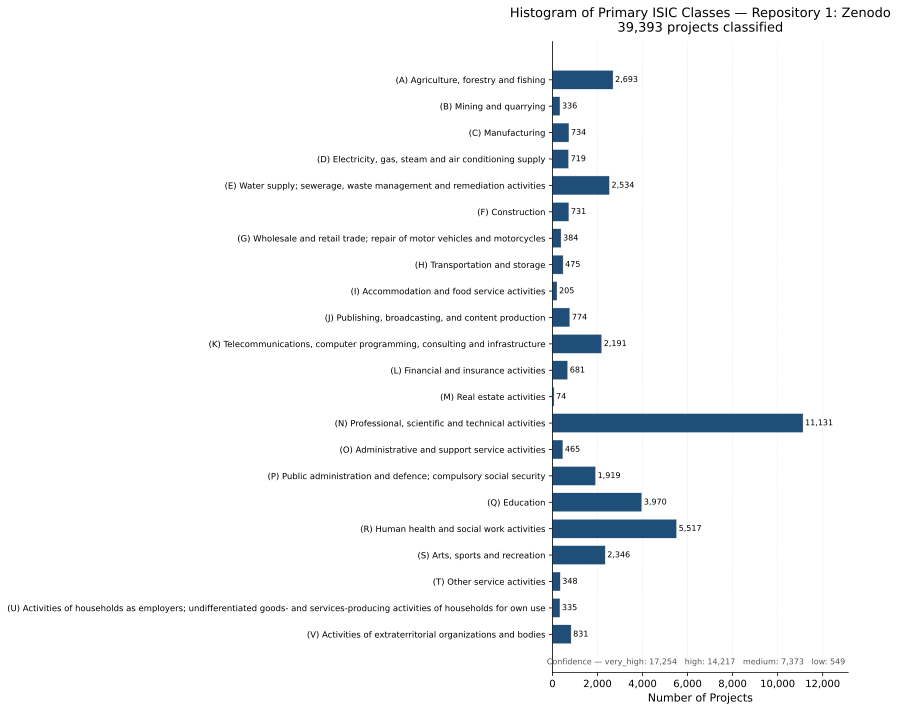

In [105]:
def plot_section_histogram(conn, repo_id):
    repo_name = REPO_NAMES[repo_id]
    rows = conn.execute("""
        SELECT cv.section, cv.section_name, COUNT(*) as cnt
        FROM projects p JOIN classifications_vote cv ON p.id=cv.project_id
        WHERE p.repository_id=? GROUP BY cv.section ORDER BY cnt DESC
    """, (repo_id,)).fetchall()
    conf_stats = conn.execute("""
        SELECT cv.confidence, COUNT(*) FROM projects p
        JOIN classifications_vote cv ON p.id=cv.project_id
        WHERE p.repository_id=? GROUP BY cv.confidence
        ORDER BY CASE cv.confidence WHEN 'very_high' THEN 1 WHEN 'high' THEN 2
        WHEN 'medium' THEN 3 ELSE 4 END
    """, (repo_id,)).fetchall()

    total = sum(c for _,_,c in rows)
    sec_dict = {s: c for s,_,c in rows}
    y_labels = [f"({s}) {ISIC_SECTIONS[s]}" for s in reversed(sorted(ISIC_SECTIONS.keys()))]
    values   = [sec_dict.get(s, 0) for s in reversed(sorted(ISIC_SECTIONS.keys()))]

    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor("white")
    y_pos = range(len(y_labels))
    bars = ax.barh(list(y_pos), values, color=BLUE_DARK, edgecolor="white", linewidth=0.4, height=0.72)
    max_val = max(values) if values else 1
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(bar.get_width() + max_val * 0.008,
                    bar.get_y() + bar.get_height() / 2,
                    f"{val:,}", va="center", ha="left", fontsize=8)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(y_labels, fontsize=8.5)
    ax.set_xlim(0, max_val * 1.18)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_xlabel("Number of Projects", fontsize=11)
    ax.set_title(
        f"Histogram of Primary ISIC Classes — Repository {repo_id}: {repo_name}\n"
        f"{total:,} projects classified",
        fontsize=13, fontweight="normal", pad=10
    )
    ax.xaxis.grid(True, linestyle="--", alpha=0.5, color=GRID_COLOR)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    conf_text = "   ".join(f"{c}: {n:,}" for c, n in conf_stats)
    ax.annotate(f"Confidence — {conf_text}", xy=(0.99, 0.01), xycoords="axes fraction",
                fontsize=8, va="bottom", ha="right", color="#555")
    plt.tight_layout()
    plt.savefig(f"{img_dir}/hist_repo{repo_id}.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_section_histogram(conn, 1)


### Figure 2a — ISIC Section Histogram · Harvard Dataverse (Repo 10)

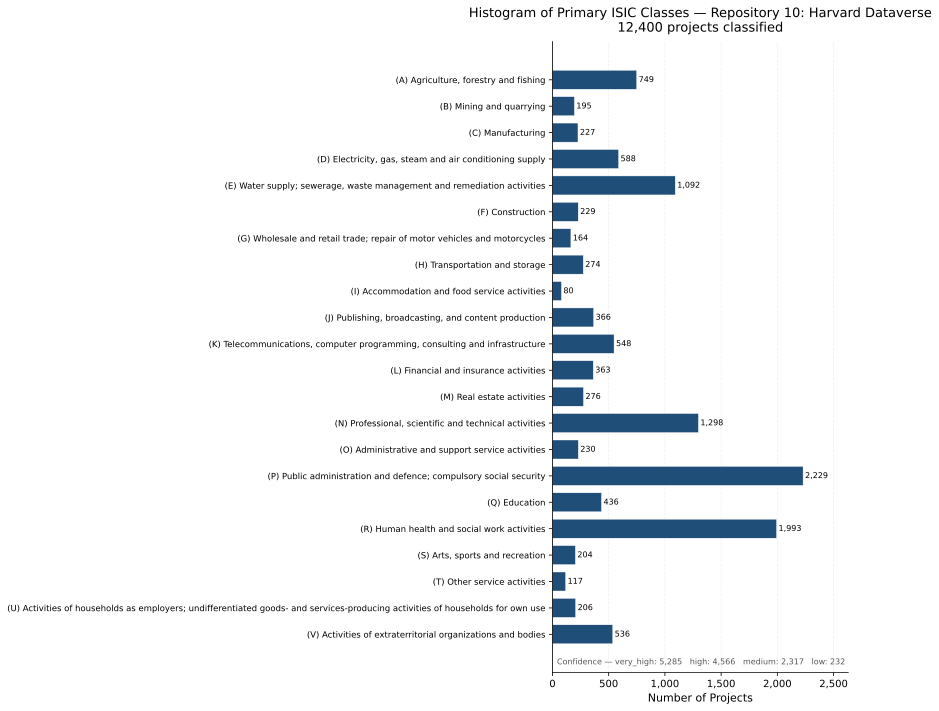

In [106]:
plot_section_histogram(conn, 10)

### Figure — ISIC Section Distribution by Confidence (stacked)

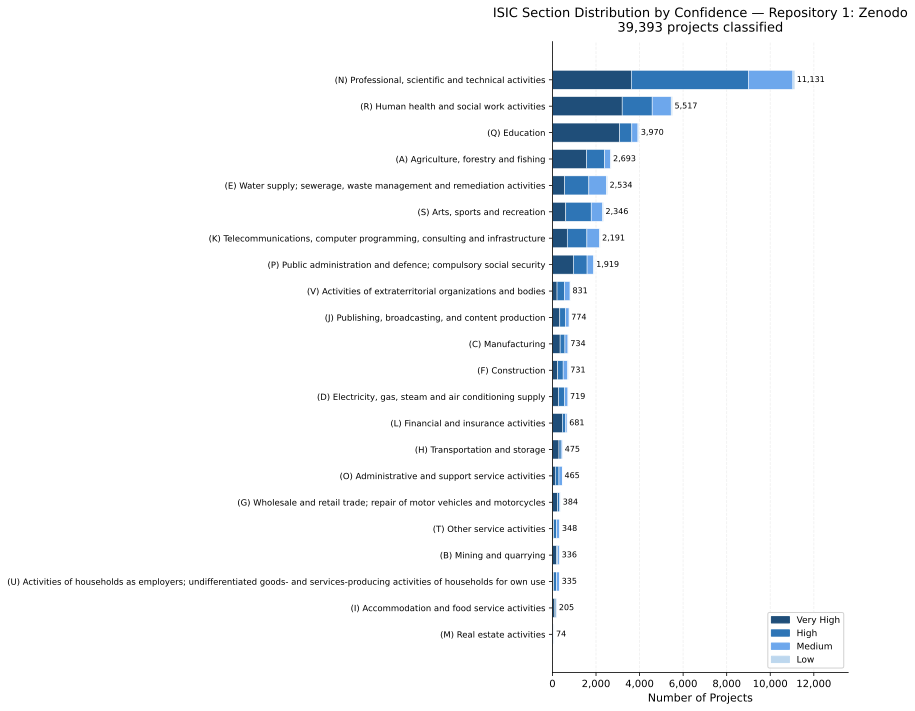

In [107]:
def plot_confidence_histogram(conn, repo_id):
    repo_name = REPO_NAMES[repo_id]
    rows = conn.execute("""
        SELECT cv.section, cv.confidence, COUNT(*) as cnt
        FROM projects p JOIN classifications_vote cv ON p.id=cv.project_id
        WHERE p.repository_id=?
        GROUP BY cv.section, cv.confidence
    """, (repo_id,)).fetchall()

    from collections import defaultdict
    sec_conf  = defaultdict(dict)
    sec_total = defaultdict(int)
    for sec, conf, cnt in rows:
        sec_conf[sec][conf] = cnt
        sec_total[sec] += cnt

    sorted_secs = sorted(sec_total.keys(), key=lambda s: sec_total[s])
    y_labels = [f"({s}) {ISIC_SECTIONS.get(s, s)}" for s in sorted_secs]
    y_pos    = range(len(sorted_secs))
    max_val  = max(sec_total.values())
    total    = sum(sec_total.values())

    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor("white")

    lefts = [0] * len(sorted_secs)
    for conf in CONF_ORDER:
        vals = [sec_conf[s].get(conf, 0) for s in sorted_secs]
        ax.barh(list(y_pos), vals, left=lefts,
                color=CONF_COLORS[conf], edgecolor="white", linewidth=0.5,
                height=0.72, label=CONF_LABELS[conf])
        lefts = [l + v for l, v in zip(lefts, vals)]

    for i, sec in enumerate(sorted_secs):
        t = sec_total[sec]
        if t > 0:
            ax.text(t + max_val * 0.008, i, f"{t:,}",
                    va="center", ha="left", fontsize=8)

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(y_labels, fontsize=8.5)
    ax.set_xlim(0, max_val * 1.22)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_xlabel("Number of Projects", fontsize=11)
    ax.set_title(
        f"ISIC Section Distribution by Confidence — Repository {repo_id}: {repo_name}\n"
        f"{total:,} projects classified",
        fontsize=13, fontweight="normal", pad=10
    )
    ax.xaxis.grid(True, linestyle="--", alpha=0.5, color=GRID_COLOR)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(handles=[Patch(color=CONF_COLORS[c], label=CONF_LABELS[c]) for c in CONF_ORDER],
              loc="lower right", fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.savefig(f"{img_dir}/conf_hist_repo{repo_id}.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_confidence_histogram(conn, 1)


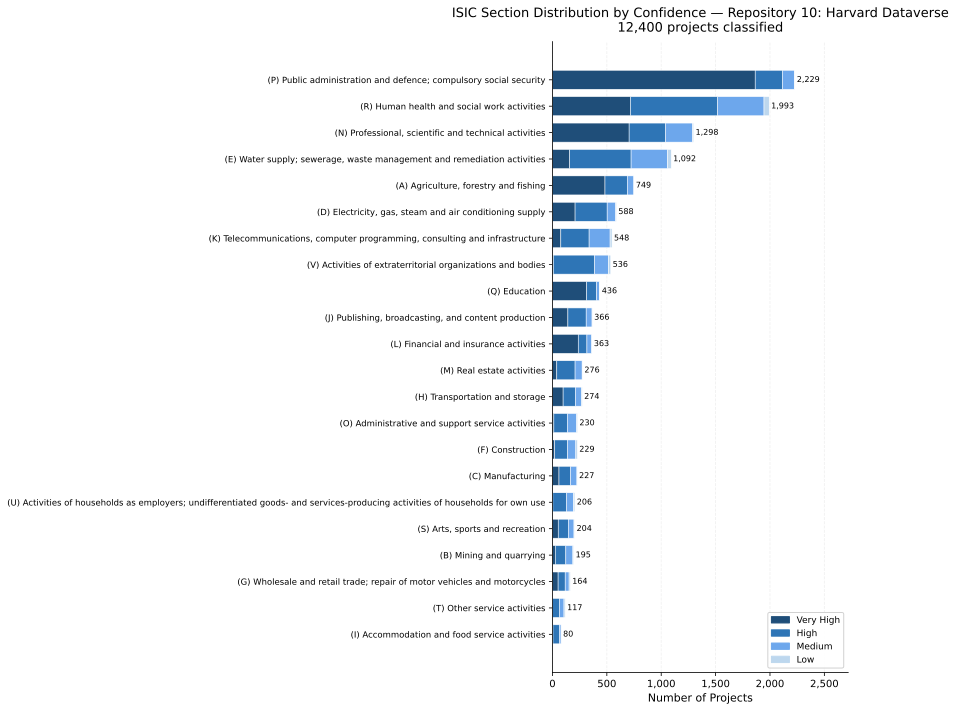

In [108]:
plot_confidence_histogram(conn, 10)

---
### Table 4a — Top-20 ISIC Classes · Zenodo (Repo 1)

In [109]:
def show_top20_table(conn, repo_id):
    repo_name = REPO_NAMES[repo_id]
    rows = conn.execute("""
        SELECT cv.section, cv.section_name,
               COALESCE(cv.division,'') as division,
               COALESCE(cv.division_name,'') as division_name,
               COUNT(*) as cnt,
               ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM projects p2
                   JOIN classifications_vote cv2 ON p2.id=cv2.project_id
                   WHERE p2.repository_id=?),1) as pct
        FROM projects p JOIN classifications_vote cv ON p.id=cv.project_id
        WHERE p.repository_id=?
        GROUP BY cv.section, cv.division ORDER BY cnt DESC LIMIT 20
    """, (repo_id, repo_id)).fetchall()

    table_data = []
    for rank, (sec, sec_name, div, div_name, cnt, pct) in enumerate(rows, 1):
        class_label = f"{div} — {div_name}" if div and div_name else (div or sec_name or "")
        table_data.append({"Rank": rank, "Sec.": sec, "Division": div or "—",
                            "Class Name": class_label, "Count": cnt, "%": pct})

    df = pd.DataFrame(table_data)
    display(df.style
        .format({"Count": "{:,}", "%": "{:.1f}%"})
        .hide(axis="index")
        .background_gradient(subset=["Count"], cmap="Blues")
        .set_caption(f"Table — Top-20 ISIC Classes · {repo_name} (Repo {repo_id})")
    )

show_top20_table(conn, 1)

Rank,Sec.,Division,Class Name,Count,%
1,N,72,72 — Scientific research and development,"9,691",24.6%
2,R,86,86 — Human health activities,"4,362",11.1%
3,Q,85,85 — Education,"3,970",10.1%
4,E,36,"36 — Water collection, treatment and supply","2,440",6.2%
5,A,01,"01 — Crop and animal production, hunting and related service activities","2,038",5.2%
6,P,84,84 — Public administration and defence; compulsory social security,"1,919",4.9%
7,K,62,"62 — Computer programming, consultancy and related activities","1,340",3.4%
8,N,74,"74 — Other professional, scientific and technical activities","1,322",3.4%
9,R,88,88 — Social work activities without accommodation,"1,138",2.9%
10,S,93,93 — Sports activities and amusement and recreation activities,877,2.2%


### Comments on Findings — Zenodo (Repo 1)

In [110]:
def print_comments(conn, repo_id):
    repo_name = REPO_NAMES[repo_id]
    sec_rows = conn.execute("""
        SELECT cv.section, cv.section_name, COUNT(*) as cnt FROM projects p
        JOIN classifications_vote cv ON p.id=cv.project_id
        WHERE p.repository_id=? GROUP BY cv.section ORDER BY cnt DESC
    """, (repo_id,)).fetchall()
    conf_rows = conn.execute("""
        SELECT cv.confidence, COUNT(*) FROM projects p
        JOIN classifications_vote cv ON p.id=cv.project_id
        WHERE p.repository_id=? GROUP BY cv.confidence
    """, (repo_id,)).fetchall()
    type_rows = conn.execute("""
        SELECT COALESCE(type,'UNKNOWN'), COUNT(*) FROM projects
        WHERE repository_id=? GROUP BY type ORDER BY COUNT(*) DESC
    """, (repo_id,)).fetchall()

    total = sum(c for _,_,c in sec_rows)
    sec_dict = {s: c for s,_,c in sec_rows}
    dom_sec, dom_cnt = list(sec_dict.items())[0]
    dom_name = ISIC_SECTIONS.get(dom_sec, "")
    n_secs = len(sec_dict)
    conf_dict = dict(conf_rows)
    high_conf = conf_dict.get("very_high",0) + conf_dict.get("high",0)
    type_str = ";  ".join(f"{t} ({c:,})" for t,c in type_rows)
    secs_list = ", ".join(sorted(sec_dict.keys()))

    comments = [
        f"Repository {repo_id} ({repo_name}) contains {total:,} classified projects across {n_secs} ISIC Rev.5 sections ({secs_list}).",
        f"Project types present: {type_str}.",
        f"The dominant ISIC section is {dom_sec} — {dom_name}, accounting for {dom_cnt:,} projects ({dom_cnt/total*100:.1f}% of the repository).",
        f"Classification confidence: {high_conf:,} projects ({high_conf/total*100:.1f}%) classified at high or very-high confidence.",
    ]
    domain_comments = {
        "N": "Section N (Professional, scientific and technical activities) is dominant. This is expected for general-purpose academic repositories where many datasets describe scientific research processes. Sub-division 72 (Scientific research and development) is typically the most frequent.",
        "A": "Section A (Agriculture, forestry and fishing) dominates, indicating a strong share of environmental, ecological, and agricultural datasets — consistent with natural-sciences open-data communities.",
        "R": "Section R (Human health and social work activities) is dominant, reflecting a focus on medical, clinical, and social datasets.",
        "P": "Section P (Public administration and defence) dominates, reflecting political-science, governance, and survey datasets typical of social science repositories.",
        "Q": "Section Q (Education) is dominant, consistent with repositories focused on educational research.",
    }
    if dom_sec in domain_comments:
        comments.append(domain_comments[dom_sec])
    if n_secs >= 18:
        comments.append(f"The distribution spans {n_secs} of 22 ISIC sections, indicating high thematic diversity.")
    elif n_secs <= 8:
        comments.append(f"With only {n_secs} sections represented, the repository has a narrow thematic focus.")

    print(f"\n{'='*70}")
    print(f"Comments on Findings — Repository {repo_id}: {repo_name}")
    print(f"{'='*70}")
    for c in comments:
        print("\n• " + textwrap.fill(c, width=80, subsequent_indent="  "))

print_comments(conn, 1)


Comments on Findings — Repository 1: Zenodo

• Repository 1 (Zenodo) contains 39,393 classified projects across 22 ISIC Rev.5
  sections (A, B, C, D, E, F, G, H, I, J, K, L, M, N, O, P, Q, R, S, T, U, V).

• Project types present: QD_PROJECT (27,655);  OTHER_PROJECT (10,180);
  NOT_A_PROJECT (1,516);  QDA_PROJECT (42).

• The dominant ISIC section is N — Professional, scientific and technical
  activities, accounting for 11,131 projects (28.3% of the repository).

• Classification confidence: 31,471 projects (79.9%) classified at high or very-
  high confidence.

• Section N (Professional, scientific and technical activities) is dominant. This
  is expected for general-purpose academic repositories where many datasets
  describe scientific research processes. Sub-division 72 (Scientific research
  and development) is typically the most frequent.

• The distribution spans 22 of 22 ISIC sections, indicating high thematic
  diversity.


### Table 4b — Top-20 ISIC Classes · Harvard Dataverse (Repo 10)

In [111]:
show_top20_table(conn, 10)

Rank,Sec.,Division,Class Name,Count,%
1,P,84,84 — Public administration and defence; compulsory social security,"2,229",18.0%
2,R,86,86 — Human health activities,"1,330",10.7%
3,N,72,72 — Scientific research and development,959,7.7%
4,E,36,"36 — Water collection, treatment and supply",875,7.1%
5,R,88,88 — Social work activities without accommodation,631,5.1%
6,D,35,"35 — Electricity, gas, steam and air conditioning supply",588,4.7%
7,A,01,"01 — Crop and animal production, hunting and related service activities",555,4.5%
8,V,99,99 — Activities of extraterritorial organizations and bodies,536,4.3%
9,Q,85,85 — Education,436,3.5%
10,L,64,"64 — Financial service activities, except insurance and pension funding",332,2.7%


### Comments on Findings — Harvard Dataverse (Repo 10)

In [112]:
print_comments(conn, 10)


Comments on Findings — Repository 10: Harvard Dataverse

• Repository 10 (Harvard Dataverse) contains 12,400 classified projects across 22
  ISIC Rev.5 sections (A, B, C, D, E, F, G, H, I, J, K, L, M, N, O, P, Q, R, S,
  T, U, V).

• Project types present: QD_PROJECT (7,022);  OTHER_PROJECT (5,115);
  NOT_A_PROJECT (241);  QDA_PROJECT (22).

• The dominant ISIC section is P — Public administration and defence; compulsory
  social security, accounting for 2,229 projects (18.0% of the repository).

• Classification confidence: 9,851 projects (79.4%) classified at high or very-
  high confidence.

• Section P (Public administration and defence) dominates, reflecting political-
  science, governance, and survey datasets typical of social science
  repositories.

• The distribution spans 22 of 22 ISIC sections, indicating high thematic
  diversity.


---
### Figure 1b — Top-15 ISIC Divisions (Secondary Classes) · Zenodo (Repo 1)

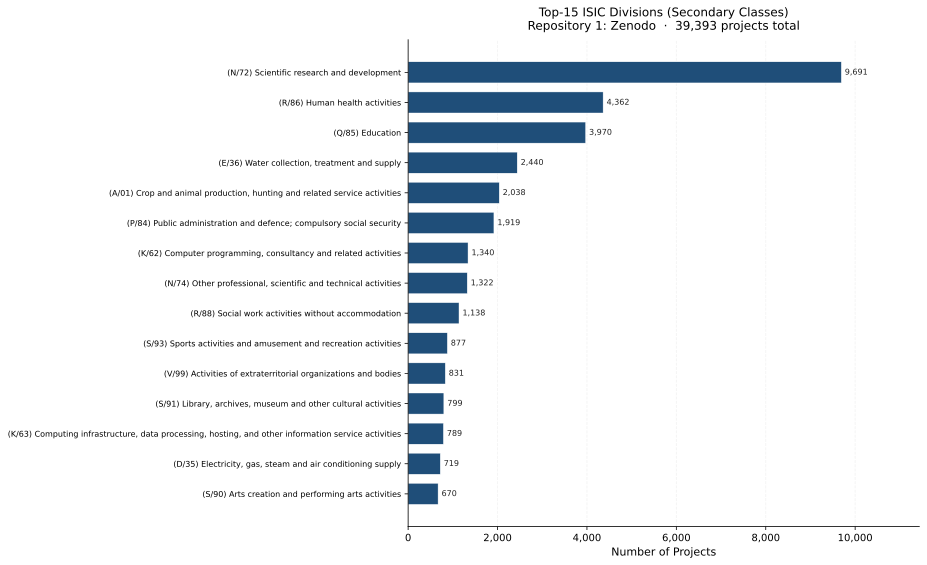

In [113]:
def plot_division_histogram(conn, repo_id, n=15):
    repo_name = REPO_NAMES[repo_id]
    rows = conn.execute("""
        SELECT cv.section, cv.division,
               COALESCE(cv.division_name, cv.section_name, '') as label,
               COUNT(*) as cnt
        FROM projects p JOIN classifications_vote cv ON p.id=cv.project_id
        WHERE p.repository_id=? AND cv.division IS NOT NULL AND cv.division != ''
        GROUP BY cv.section, cv.division ORDER BY cnt DESC LIMIT ?
    """, (repo_id, n)).fetchall()

    total_row = conn.execute("""
        SELECT COUNT(*) FROM projects p
        JOIN classifications_vote cv ON p.id=cv.project_id
        WHERE p.repository_id=?
    """, (repo_id,)).fetchone()
    total = total_row[0] if total_row else 0

    if not rows:
        print(f"No division data for {repo_name}.")
        return

    # Full labels: (section/division) full division name — bottom to top
    labels = [f"({sec}/{div}) {lbl}" for sec, div, lbl, _ in reversed(rows)]
    values = [cnt for *_, cnt in reversed(rows)]

    fig, ax = plt.subplots(figsize=(13, 8))
    fig.patch.set_facecolor("white")

    y_pos = range(len(labels))
    bars = ax.barh(list(y_pos), values, color=BLUE_DARK, edgecolor="white", linewidth=0.4, height=0.7)

    max_val = max(values)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + max_val * 0.008, bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", ha="left", fontsize=8, color="#222")

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlim(0, max_val * 1.18)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_xlabel("Number of Projects", fontsize=11)
    ax.set_title(
        f"Top-{n} ISIC Divisions (Secondary Classes)\n"
        f"Repository {repo_id}: {repo_name}  ·  {total:,} projects total",
        fontsize=12, pad=10, fontweight="normal"
    )
    ax.xaxis.grid(True, linestyle="--", alpha=0.4, color=GRID_COLOR)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)



    plt.tight_layout()
    plt.savefig(f"{img_dir}/div_repo{repo_id}.png")
    plt.show()

plot_division_histogram(conn, 1)

### Figure 2b — Top-15 ISIC Divisions · Harvard Dataverse (Repo 10)

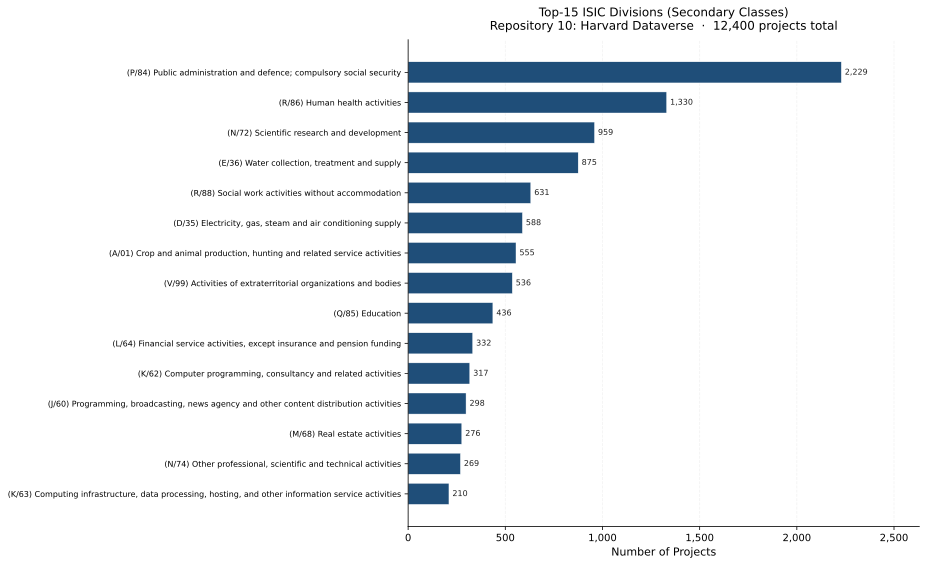

In [114]:
plot_division_histogram(conn, 10)

### Figure — Top-15 ISIC Divisions by Confidence (stacked)

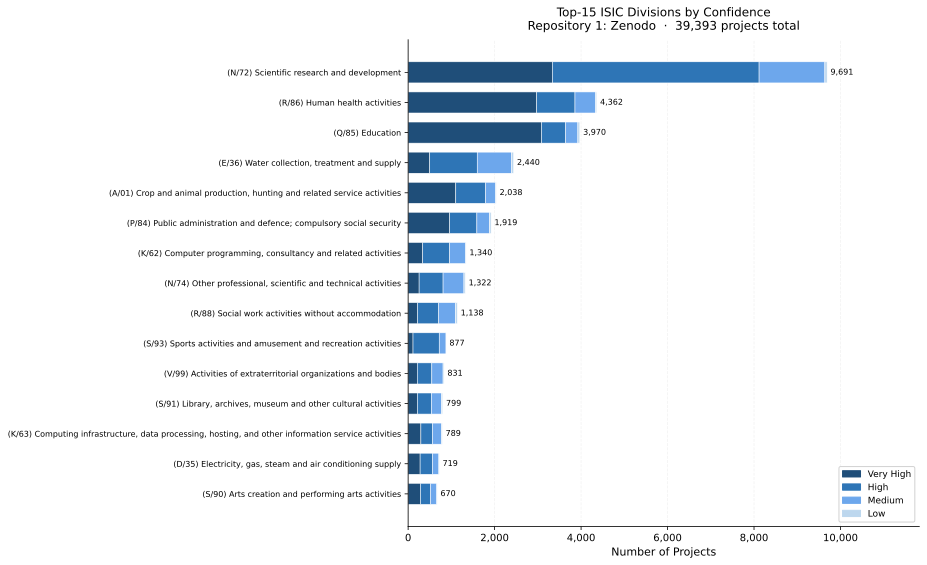

In [115]:
def plot_confidence_division_histogram(conn, repo_id, n=15):
    repo_name = REPO_NAMES[repo_id]

    rows = conn.execute("""
        SELECT cv.division,
               COALESCE(cv.division_name, cv.section_name, '') as label,
               cv.section,
               cv.confidence,
               COUNT(*) as cnt
        FROM projects p JOIN classifications_vote cv ON p.id=cv.project_id
        WHERE p.repository_id=? AND cv.division IS NOT NULL AND cv.division != ''
        GROUP BY cv.division, cv.confidence
    """, (repo_id,)).fetchall()

    if not rows:
        print(f"No division data for {repo_name}.")
        return

    from collections import defaultdict
    div_conf  = defaultdict(dict)
    div_total = defaultdict(int)
    div_meta  = {}   # div → (section, label)
    for div, lbl, sec, conf, cnt in rows:
        div_conf[div][conf] = cnt
        div_total[div] += cnt
        div_meta[div] = (sec, lbl)

    # Keep top-n by total, sort ascending (largest at top)
    top_divs = sorted(div_total, key=lambda d: div_total[d], reverse=True)[:n]
    top_divs = sorted(top_divs, key=lambda d: div_total[d])  # ascending for barh

    labels  = [f"({div_meta[d][0]}/{d}) {div_meta[d][1]}" for d in top_divs]
    y_pos   = range(len(top_divs))
    max_val = max(div_total[d] for d in top_divs)
    total   = conn.execute("""
        SELECT COUNT(*) FROM projects p
        JOIN classifications_vote cv ON p.id=cv.project_id
        WHERE p.repository_id=?
    """, (repo_id,)).fetchone()[0]

    fig, ax = plt.subplots(figsize=(13, 8))
    fig.patch.set_facecolor("white")

    lefts = [0] * len(top_divs)
    for conf in CONF_ORDER:
        vals = [div_conf[d].get(conf, 0) for d in top_divs]
        ax.barh(list(y_pos), vals, left=lefts,
                color=CONF_COLORS[conf], edgecolor="white", linewidth=0.5,
                height=0.7, label=CONF_LABELS[conf])
        lefts = [l + v for l, v in zip(lefts, vals)]

    for i, d in enumerate(top_divs):
        t = div_total[d]
        ax.text(t + max_val * 0.008, i, f"{t:,}",
                va="center", ha="left", fontsize=8)

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlim(0, max_val * 1.22)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_xlabel("Number of Projects", fontsize=11)
    ax.set_title(
        f"Top-{n} ISIC Divisions by Confidence\n"
        f"Repository {repo_id}: {repo_name}  ·  {total:,} projects total",
        fontsize=12, pad=10, fontweight="normal"
    )
    ax.xaxis.grid(True, linestyle="--", alpha=0.4, color=GRID_COLOR)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(handles=[Patch(color=CONF_COLORS[c], label=CONF_LABELS[c]) for c in CONF_ORDER],
              loc="lower right", fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.savefig(f"{img_dir}/conf_div_repo{repo_id}.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_confidence_division_histogram(conn, 1)


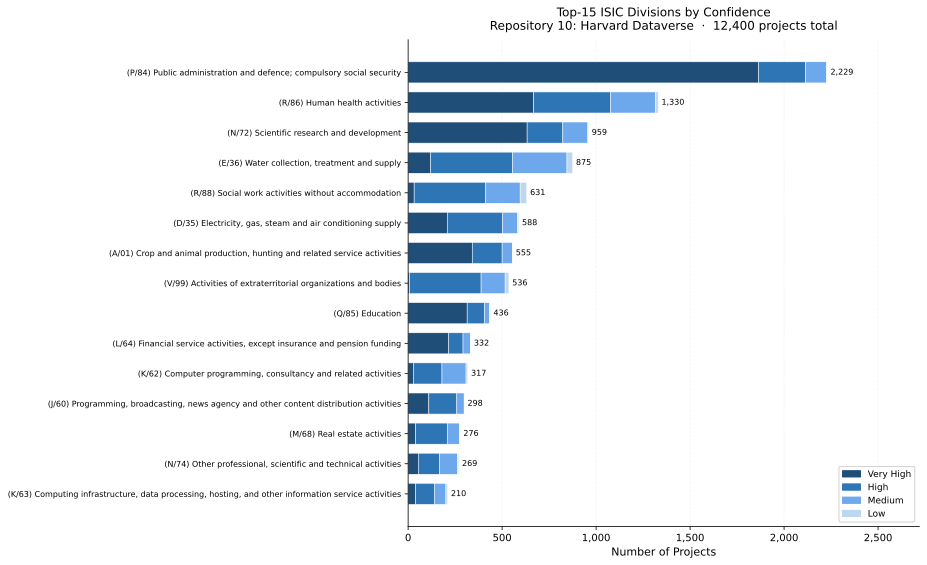

In [116]:
plot_confidence_division_histogram(conn, 10)

---
## Part 3 — Cross-Repository Overview
### Figure 4 — Section Distribution Across All Repositories

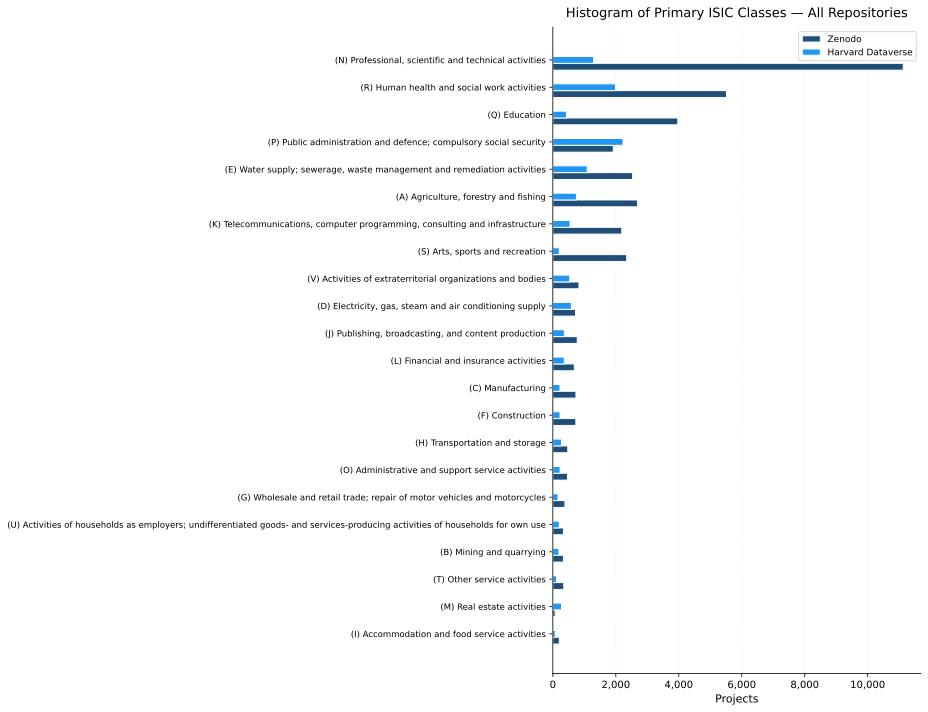

In [117]:
df_all_sec = pd.read_sql("""
    SELECT p.repository_id, cv.section, COUNT(*) as cnt
    FROM classifications_vote cv JOIN projects p ON p.id=cv.project_id
    WHERE cv.section IS NOT NULL GROUP BY p.repository_id, cv.section
""", conn)
df_all_sec["repository"] = df_all_sec["repository_id"].map(REPO_NAMES)

pivot_sec = df_all_sec.pivot_table(index="section", columns="repository", values="cnt", fill_value=0)
pivot_sec["Total"] = pivot_sec.sum(axis=1)
pivot_sec = pivot_sec.sort_values("Total", ascending=True)  # ascending so largest is at top

repos = [r for r in REPO_NAMES.values() if r in pivot_sec.columns]
repo_colors = ["#1F4E79", "#2196F3", "#90CAF9"]

y_labels = [f"({s}) {ISIC_SECTIONS.get(s, s)}" for s in pivot_sec.index]
y_pos = np.arange(len(y_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 10))
for i, (repo, color) in enumerate(zip(repos, repo_colors)):
    ax.barh(y_pos + i * width, pivot_sec[repo], width, label=repo, color=color, edgecolor="white")

ax.set_yticks(y_pos + width)
ax.set_yticklabels(y_labels, fontsize=8.5)
ax.set_xlabel("Projects", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_title("Histogram of Primary ISIC Classes — All Repositories", fontsize=13, fontweight="normal", pad=10)
ax.legend(fontsize=9)
ax.xaxis.grid(True, linestyle="--", alpha=0.4, color=GRID_COLOR)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Table 5 — ISIC Section Distribution Across All Repositories

In [118]:
df_sec_table = pd.read_sql("""
    SELECT cv.section, cv.section_name, COUNT(*) as total
    FROM classifications_vote cv WHERE cv.section IS NOT NULL
    GROUP BY cv.section, cv.section_name ORDER BY total DESC
""", conn)

df_sec_table["Share %"] = (df_sec_table["total"] / df_sec_table["total"].sum() * 100).round(1)
df_sec_table.columns = ["Section", "Section Name", "Total Projects", "Share %"]

display(df_sec_table.style
    .format({"Total Projects": "{:,}", "Share %": "{:.1f}%"})
    .bar(subset=["Total Projects"], color="#9DC3E6")
    .hide(axis="index")
    .set_caption("Table 5 — ISIC section distribution (all repositories combined)")
)

Section,Section Name,Total Projects,Share %
N,"Professional, scientific and technical activities","12,439",24.0%
R,Human health and social work activities,"7,521",14.5%
Q,Education,"4,407",8.5%
P,Public administration and defence; compulsory social security,"4,148",8.0%
E,"Water supply; sewerage, waste management and remediation activities","3,626",7.0%
A,"Agriculture, forestry and fishing","3,442",6.6%
K,"Telecommunications, computer programming, consultancy, computing infrastructure, and other information service activities","2,739",5.3%
S,"Arts, sports and recreation","2,550",4.9%
V,Activities of extraterritorial organizations and bodies,"1,367",2.6%
D,"Electricity, gas, steam and air conditioning supply","1,307",2.5%


---
## Part 4 — File-Level Classification (BERT)
### Table 6 — File Classification Summary

In [119]:
df_files_sum = pd.read_sql("""
    SELECT p.repository_id,
           COUNT(*) as files_classified,
           SUM(CASE WHEN cf.confidence='very_high' THEN 1 ELSE 0 END) as very_high,
           SUM(CASE WHEN cf.confidence='high'      THEN 1 ELSE 0 END) as high,
           SUM(CASE WHEN cf.confidence='medium'    THEN 1 ELSE 0 END) as medium,
           SUM(CASE WHEN cf.confidence='low'       THEN 1 ELSE 0 END) as low
    FROM classifications_files cf
    JOIN projects p ON p.id=cf.project_id
    GROUP BY p.repository_id
""", conn)

df_files_sum["Repository"] = df_files_sum["repository_id"].map(REPO_NAMES)
df_files_sum["%very_high"] = (df_files_sum["very_high"] / df_files_sum["files_classified"] * 100).round(1)
df_files_sum = df_files_sum[["Repository","files_classified","very_high","high","medium","low","%very_high"]]
df_files_sum.columns = ["Repository","Files Classified","very_high","high","medium","low","% very_high"]

display(df_files_sum.style
    .format({c: "{:,}" for c in ["Files Classified","very_high","high","medium","low"]})
    .format({"% very_high": "{:.1f}%"})
    .bar(subset=["% very_high"], color="#9DC3E6")
    .hide(axis="index")
    .set_caption("Table 6 — File-level BERT classification summary")
)

Repository,Files Classified,very_high,high,medium,low,% very_high
Zenodo,14689,10007,2339,1682,661,68.1%
Harvard Dataverse,2312,1523,377,331,81,65.9%


### Figure 5a/5b — File-Level ISIC Section Distribution (one chart per repository)

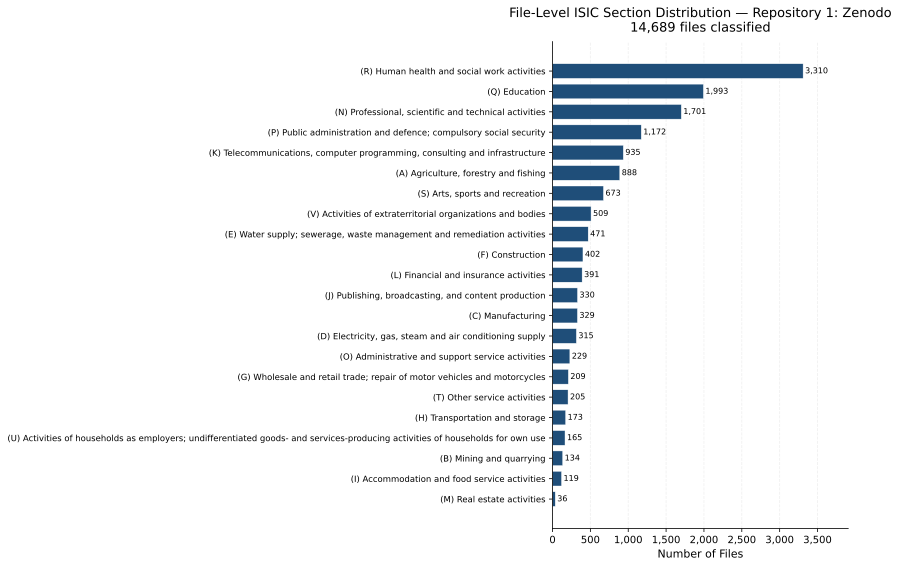

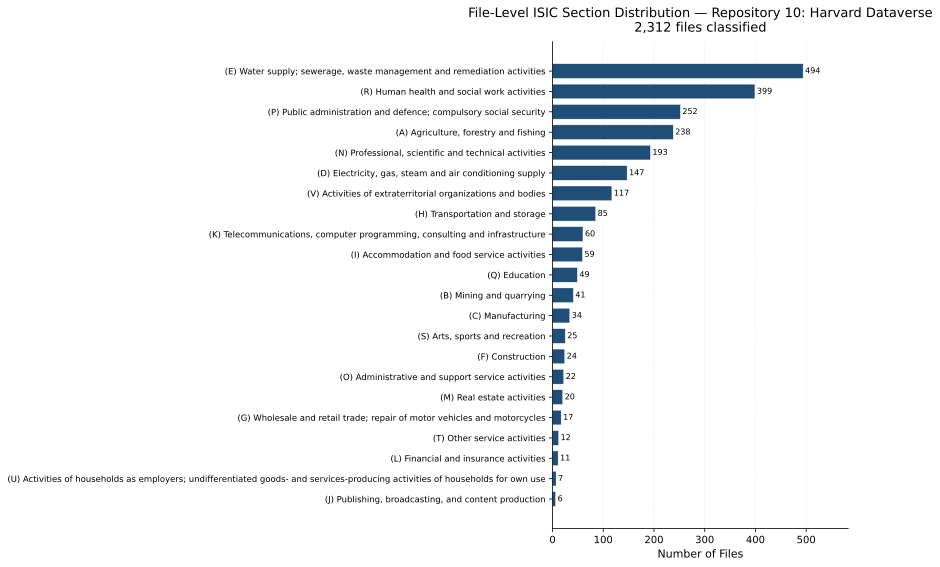

In [120]:
df_fsec_plain = pd.read_sql("""
    SELECT p.repository_id, cf.section, COUNT(*) as cnt
    FROM classifications_files cf JOIN projects p ON p.id=cf.project_id
    WHERE cf.section IS NOT NULL
    GROUP BY p.repository_id, cf.section
    ORDER BY p.repository_id, cnt DESC
""", conn)

for repo_id, repo_name in REPO_NAMES.items():
    sub = df_fsec_plain[df_fsec_plain["repository_id"] == repo_id].copy()
    if sub.empty:
        print(f"No file classifications for {repo_name}.")
        continue
    sub = sub.sort_values("cnt", ascending=True)
    sub["label"] = sub["section"].apply(lambda s: f"({s}) {ISIC_SECTIONS.get(s, s)}")

    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor("white")
    y_pos = range(len(sub))
    bars = ax.barh(list(y_pos), sub["cnt"].values, color=BLUE_DARK,
                   edgecolor="white", linewidth=0.4, height=0.72)
    max_val = sub["cnt"].max()
    for bar, val in zip(bars, sub["cnt"].values):
        ax.text(bar.get_width() + max_val * 0.008,
                bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", ha="left", fontsize=8)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(sub["label"].values, fontsize=8.5)
    ax.set_xlim(0, max_val * 1.18)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_xlabel("Number of Files", fontsize=11)
    ax.set_title(
        f"File-Level ISIC Section Distribution — Repository {repo_id}: {repo_name}\n"
        f"{sub['cnt'].sum():,} files classified",
        fontsize=13, fontweight="normal", pad=10
    )
    ax.xaxis.grid(True, linestyle="--", alpha=0.5, color=GRID_COLOR)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{img_dir}/file_hist_repo{repo_id}.png", dpi=150, bbox_inches="tight")
    plt.show()


### Figure — File-Level ISIC Section Distribution by Confidence (stacked)

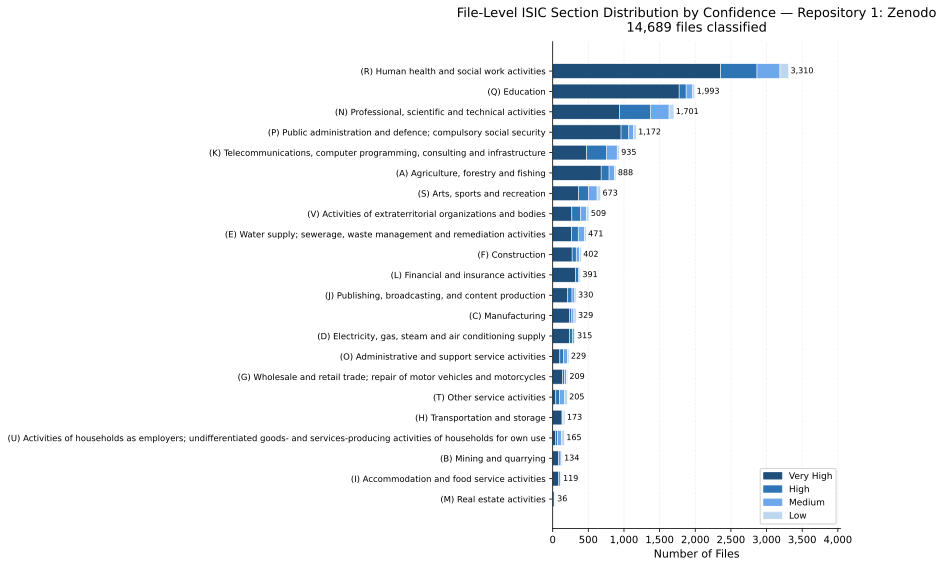

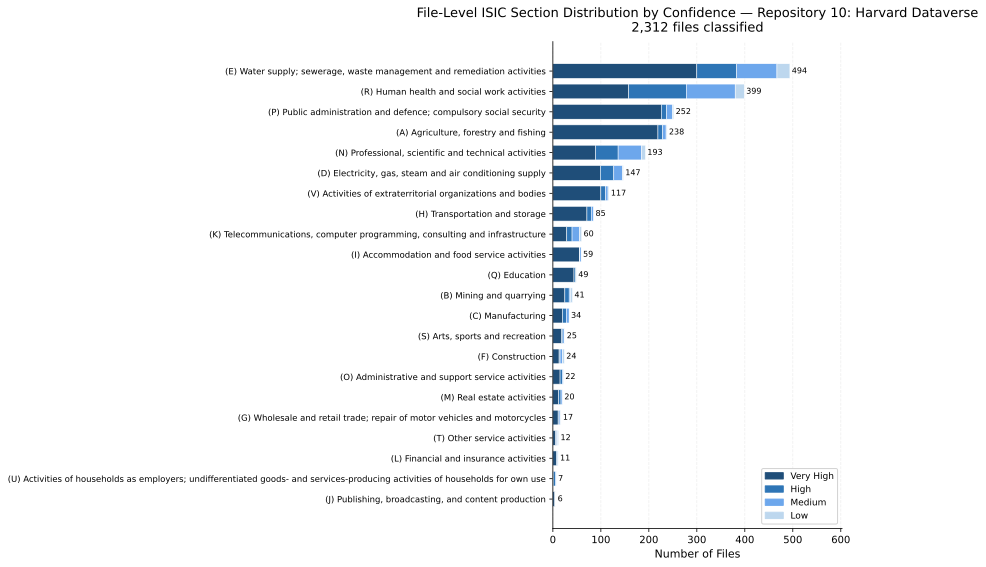

In [121]:
df_fsec_conf = pd.read_sql("""
    SELECT p.repository_id, cf.section, cf.confidence, COUNT(*) as cnt
    FROM classifications_files cf JOIN projects p ON p.id=cf.project_id
    WHERE cf.section IS NOT NULL
    GROUP BY p.repository_id, cf.section, cf.confidence
""", conn)

for repo_id, repo_name in REPO_NAMES.items():
    sub = df_fsec_conf[df_fsec_conf["repository_id"] == repo_id].copy()
    if sub.empty:
        continue

    sec_total = sub.groupby("section")["cnt"].sum()
    sorted_secs = sec_total.sort_values(ascending=True).index.tolist()
    y_labels = [f"({s}) {ISIC_SECTIONS.get(s, s)}" for s in sorted_secs]
    y_pos    = range(len(sorted_secs))
    max_val  = int(sec_total.max())
    total    = int(sec_total.sum())

    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor("white")

    lefts = [0] * len(sorted_secs)
    for conf in CONF_ORDER:
        conf_sub = sub[sub["confidence"] == conf].set_index("section")["cnt"]
        vals = [int(conf_sub.get(s, 0)) for s in sorted_secs]
        ax.barh(list(y_pos), vals, left=lefts,
                color=CONF_COLORS[conf], edgecolor="white", linewidth=0.5,
                height=0.72, label=CONF_LABELS[conf])
        lefts = [l + v for l, v in zip(lefts, vals)]

    for i, sec in enumerate(sorted_secs):
        t = int(sec_total[sec])
        if t > 0:
            ax.text(t + max_val * 0.008, i, f"{t:,}",
                    va="center", ha="left", fontsize=8)

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(y_labels, fontsize=8.5)
    ax.set_xlim(0, max_val * 1.22)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_xlabel("Number of Files", fontsize=11)
    ax.set_title(
        f"File-Level ISIC Section Distribution by Confidence — Repository {repo_id}: {repo_name}\n"
        f"{total:,} files classified",
        fontsize=13, fontweight="normal", pad=10
    )
    ax.xaxis.grid(True, linestyle="--", alpha=0.5, color=GRID_COLOR)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(handles=[Patch(color=CONF_COLORS[c], label=CONF_LABELS[c]) for c in CONF_ORDER],
              loc="lower right", fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.savefig(f"{img_dir}/file_conf_hist_repo{repo_id}.png", dpi=150, bbox_inches="tight")
    plt.show()


### Figure 6a/6b — File-Level ISIC Division Distribution (Top-15, one chart per repository)

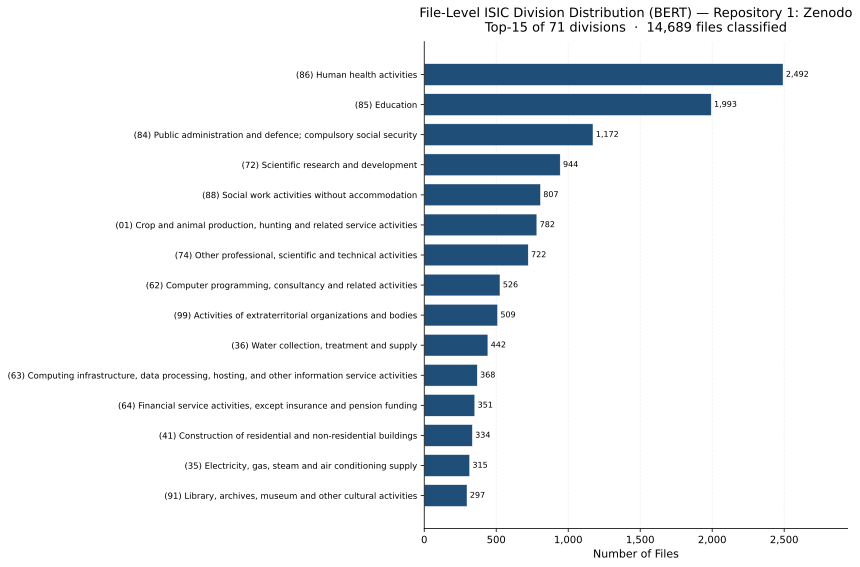

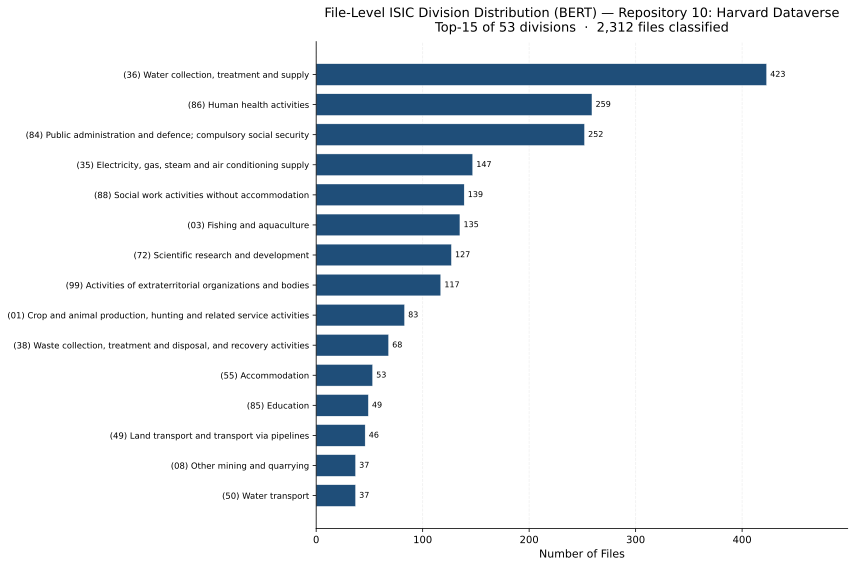

In [122]:
df_fdiv = pd.read_sql("""
    SELECT p.repository_id, cf.division, cf.division_name, COUNT(*) as cnt
    FROM classifications_files cf JOIN projects p ON p.id=cf.project_id
    WHERE cf.division IS NOT NULL
    GROUP BY p.repository_id, cf.division
    ORDER BY p.repository_id, cnt DESC
""", conn)

for repo_id, repo_name in REPO_NAMES.items():
    sub = df_fdiv[df_fdiv["repository_id"] == repo_id].head(15).copy()
    if sub.empty:
        print(f"No file division data for {repo_name}.")
        continue

    sub = sub.sort_values("cnt", ascending=True)  # largest at top
    sub["label"] = sub.apply(
        lambda r: f"({r['division']}) {r['division_name']}" if r['division_name']
                  else f"({r['division']})", axis=1
    )

    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor("white")
    y_pos = range(len(sub))
    bars = ax.barh(list(y_pos), sub["cnt"].values, color=BLUE_DARK,
                   edgecolor="white", linewidth=0.4, height=0.72)

    max_val = sub["cnt"].max()
    for bar, val in zip(bars, sub["cnt"].values):
        ax.text(bar.get_width() + max_val * 0.008,
                bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", ha="left", fontsize=8)

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(sub["label"].values, fontsize=8.5)
    ax.set_xlim(0, max_val * 1.18)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_xlabel("Number of Files", fontsize=11)
    total_div_files = int(df_fdiv[df_fdiv["repository_id"] == repo_id]["cnt"].sum())
    ax.set_title(
        f"File-Level ISIC Division Distribution (BERT) — Repository {repo_id}: {repo_name}\n"
        f"Top-15 of {len(df_fdiv[df_fdiv['repository_id']==repo_id])} divisions  ·  {total_div_files:,} files classified",
        fontsize=13, fontweight="normal", pad=10
    )
    ax.xaxis.grid(True, linestyle="--", alpha=0.5, color=GRID_COLOR)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    os.makedirs(img_dir, exist_ok=True)
    plt.tight_layout()
    plt.savefig(f"{img_dir}/file_div_repo{repo_id}.png", dpi=150, bbox_inches="tight")
    plt.show()


### Figure — File-Level Top-15 ISIC Divisions by Confidence (stacked)

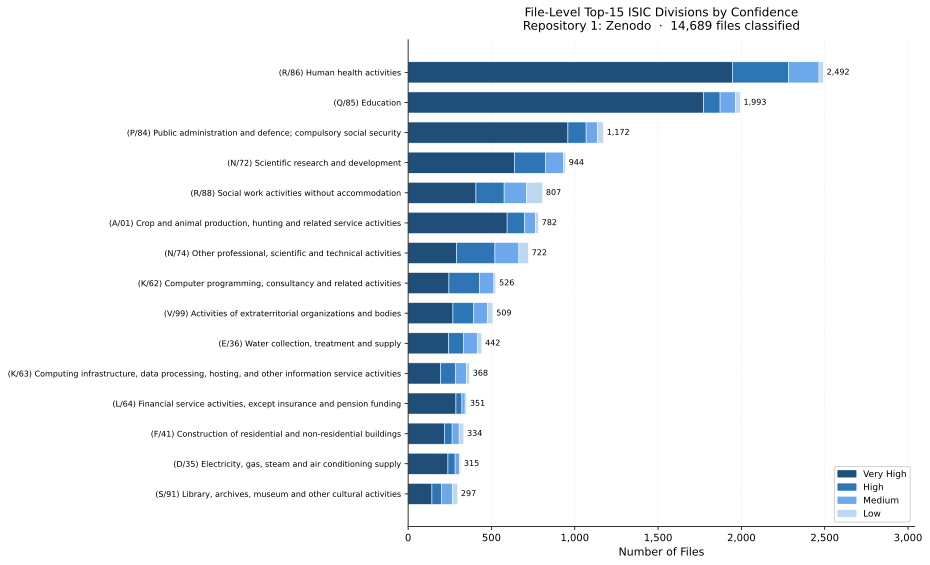

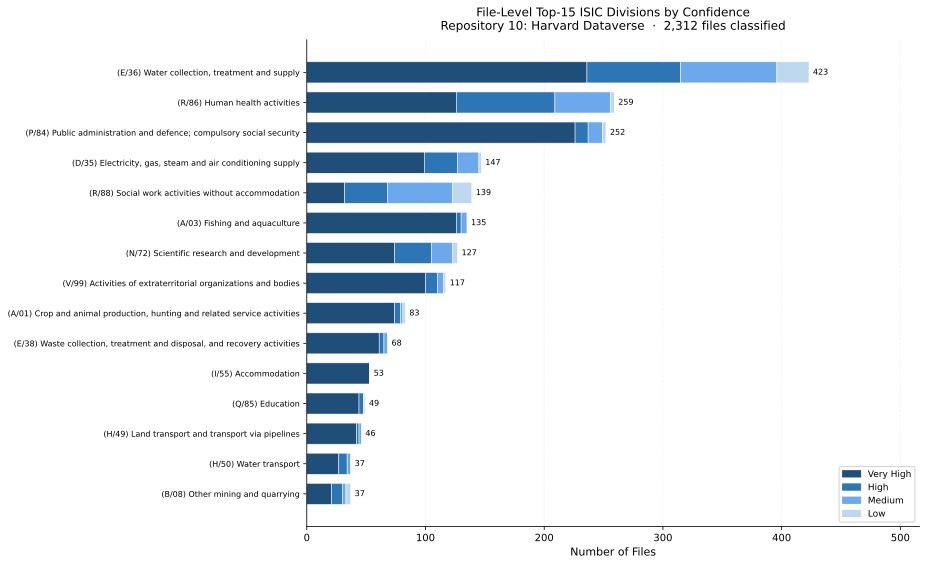

In [123]:
df_fdiv_conf = pd.read_sql("""
    SELECT p.repository_id, cf.division, cf.division_name, cf.section,
           cf.confidence, COUNT(*) as cnt
    FROM classifications_files cf JOIN projects p ON p.id=cf.project_id
    WHERE cf.division IS NOT NULL
    GROUP BY p.repository_id, cf.division, cf.confidence
""", conn)

for repo_id, repo_name in REPO_NAMES.items():
    sub = df_fdiv_conf[df_fdiv_conf["repository_id"] == repo_id].copy()
    if sub.empty:
        continue

    from collections import defaultdict
    div_conf  = defaultdict(dict)
    div_total = defaultdict(int)
    div_meta  = {}
    for _, row in sub.iterrows():
        d = row["division"]
        div_conf[d][row["confidence"]] = row["cnt"]
        div_total[d] += row["cnt"]
        div_meta[d]   = (row["section"], row["division_name"] or d)

    top_divs = sorted(div_total, key=lambda d: div_total[d], reverse=True)[:15]
    top_divs = sorted(top_divs, key=lambda d: div_total[d])

    labels  = [f"({div_meta[d][0]}/{d}) {div_meta[d][1]}" for d in top_divs]
    y_pos   = range(len(top_divs))
    max_val = max(div_total[d] for d in top_divs)
    total   = int(sub["cnt"].sum())

    fig, ax = plt.subplots(figsize=(13, 8))
    fig.patch.set_facecolor("white")

    lefts = [0] * len(top_divs)
    for conf in CONF_ORDER:
        vals = [div_conf[d].get(conf, 0) for d in top_divs]
        ax.barh(list(y_pos), vals, left=lefts,
                color=CONF_COLORS[conf], edgecolor="white", linewidth=0.5,
                height=0.7, label=CONF_LABELS[conf])
        lefts = [l + v for l, v in zip(lefts, vals)]

    for i, d in enumerate(top_divs):
        t = div_total[d]
        ax.text(t + max_val * 0.008, i, f"{t:,}",
                va="center", ha="left", fontsize=8)

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlim(0, max_val * 1.22)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_xlabel("Number of Files", fontsize=11)
    ax.set_title(
        f"File-Level Top-15 ISIC Divisions by Confidence\n"
        f"Repository {repo_id}: {repo_name}  ·  {total:,} files classified",
        fontsize=12, pad=10, fontweight="normal"
    )
    ax.xaxis.grid(True, linestyle="--", alpha=0.4, color=GRID_COLOR)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(handles=[Patch(color=CONF_COLORS[c], label=CONF_LABELS[c]) for c in CONF_ORDER],
              loc="lower right", fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.savefig(f"{img_dir}/file_conf_div_repo{repo_id}.png", dpi=150, bbox_inches="tight")
    plt.show()


### Table 7 — Top-10 ISIC Sections at File Level (All Repos)

In [124]:
df_ftop = pd.read_sql("""
    SELECT cf.section, cf.section_name, COUNT(*) as files,
           ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM classifications_files),1) as pct
    FROM classifications_files cf
    WHERE cf.section IS NOT NULL
    GROUP BY cf.section, cf.section_name ORDER BY files DESC LIMIT 10
""", conn)
df_ftop.columns = ["Section","Section Name","Files","Share %"]

display(df_ftop.style
    .format({"Files": "{:,}", "Share %": "{:.1f}%"})
    .bar(subset=["Files"], color="#9DC3E6")
    .hide(axis="index")
    .set_caption("Table 7 — Top-10 ISIC sections at file level (all repositories)")
)

Section,Section Name,Files,Share %
R,Human health and social work activities,"3,709",21.8%
Q,Education,"2,042",12.0%
N,"Professional, scientific and technical activities","1,894",11.1%
P,Public administration and defence; compulsory social security,"1,424",8.4%
A,"Agriculture, forestry and fishing","1,126",6.6%
K,"Telecommunications, computer programming, consultancy, computing infrastructure, and other information service activities",995,5.9%
E,"Water supply; sewerage, waste management and remediation activities",965,5.7%
S,"Arts, sports and recreation",698,4.1%
V,Activities of extraterritorial organizations and bodies,626,3.7%
D,"Electricity, gas, steam and air conditioning supply",462,2.7%


In [125]:
conn.close()
print("All figures and tables generated.")

All figures and tables generated.
